# mjo_cross

- "Calculate space-time cross spectrum over multiple segments"
- [NCL Reference](https://www.ncl.ucar.edu/Document/Functions/Diagnostics/mjo_cross.shtml)

### Input Data
- X: (time, lat, lon)
- Y: (time, lat, lon)
- segLength: length of segment
- segOverlap: overlap of the segment

### Returns:
Three-dimensional array (16, wavenumber, frequency)

In [1]:
import os
import xarray as xr
import numpy as np
from scipy import signal # csd: cross-spectral density

In [2]:
u850_data = xr.open_dataset(os.getcwd() + "/data/anomaly/QBOi.EXP1.AMIP.001.u850.day.anom.nc")
u850_data

<xarray.Dataset> Size: 565MB
Dimensions:  (time: 2555, lat: 192, lon: 288)
Coordinates:
  * time     (time) object 20kB 1975-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
Data variables:
    date     (time) float64 20kB ...
    U850     (time, lat, lon) float32 565MB ...

In [3]:
flut_data = xr.open_dataset(os.getcwd() + "/data/anomaly/QBOi.EXP1.AMIP.001.flut.day.anom.nc")
flut_data

<xarray.Dataset> Size: 565MB
Dimensions:  (time: 2555, lat: 192, lon: 288)
Coordinates:
  * time     (time) object 20kB 1975-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
Data variables:
    date     (time) float64 20kB ...
    FLUT     (time, lat, lon) float32 565MB ...
Attributes:
    history:  Thu Mar  6 13:31:31 2025: ncatted -a cell_methods,FLUT,m,c,time...
    NCO:      netCDF Operators version 5.3.1 (Homepage = http://nco.sf.net, C...

In [4]:
segLen = 256        # 256 time steps (256 days in daily data)
segOverLap = 50     # 15 time steps of overlap

freqs, csd = signal.csd(u850_data["U850"], flut_data["FLUT"],
                        nperseg=segLen, noverlap=segOverLap)

In [5]:
csd_mag = np.abs(csd)
csd_phase = np.angle(csd, deg=True)

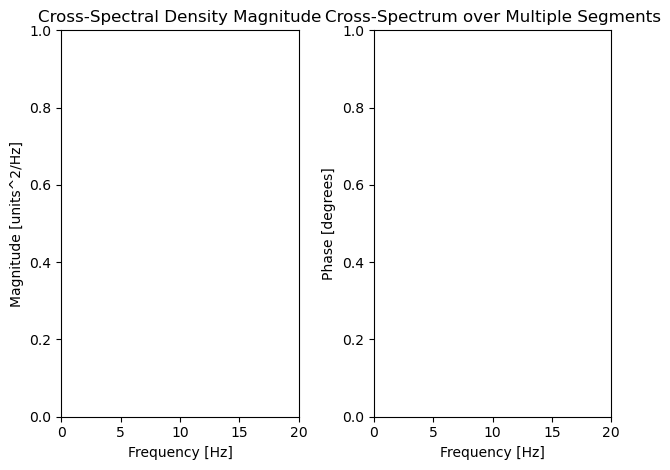

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True)

#ax1.semilogy(freqs, csd_mag)
ax1.set_title('Cross-Spectral Density Magnitude')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel('Magnitude [units^2/Hz]')
ax1.set_xlim(0, 20) # Focus on relevant frequencies

#ax2.plot(freqs, csd_phase)
ax2.set_title('Cross-Spectral Density Phase Angle')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Phase [degrees]')
ax2.set_xlim(0, 20)

plt.title("Cross-Spectrum over Multiple Segments")
plt.tight_layout()
plt.show()

### Example NCL Script and Output

- mjo_cross.ncl
- mjo_output/mjo_cross_output.txt

### Example Plot fom `mjo_cross.ncl`

- mjo_output/mjo_cross.png

<center>
<img src="mjo_output/mjo_cross.png" width="400" height="600">
</center>